## Regression Matrix

#### Regression metrics ka use machine learning (especially regression models) ki performance evaluate karne ke liye hota hai — yani model kitna accurate numeric prediction kar raha hai.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("placement.csv")

In [4]:
df.head()


,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [5]:
df.shape

(200, 2)

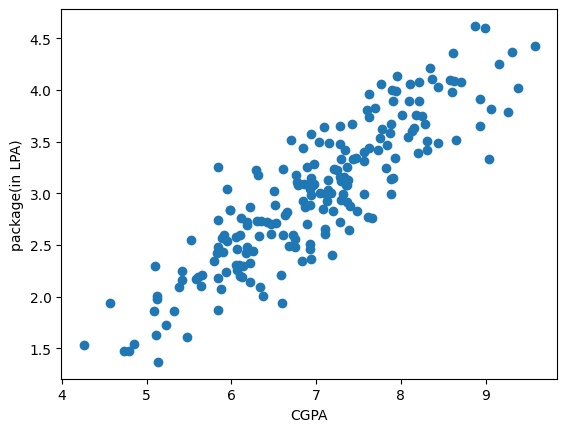

In [6]:
plt.scatter(df["cgpa"] , df["package"])
plt.xlabel("CGPA")
plt.ylabel("package(in LPA)")
plt.show()

In [7]:
X = df.iloc[:,0:1]
y = df.iloc[:,-1]


In [8]:
X

,cgpa
0,6.89
1,5.12
2,7.82
3,7.42
4,6.94
...,...
195,6.93
196,5.89
197,7.21
198,7.63


In [9]:
y

0      3.26
1      1.98
2      3.25
3      3.67
4      3.57
       ... 
195    2.46
196    2.57
197    3.24
198    3.96
199    2.33
Name: package, Length: 200, dtype: float64

In [11]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size = 0.2 , random_state = 2)


In [13]:
from sklearn.linear_model import LinearRegression

In [14]:
lr = LinearRegression()

In [15]:
lr.fit(X_train , y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Text(0, 0.5, 'Package(in lpa)')

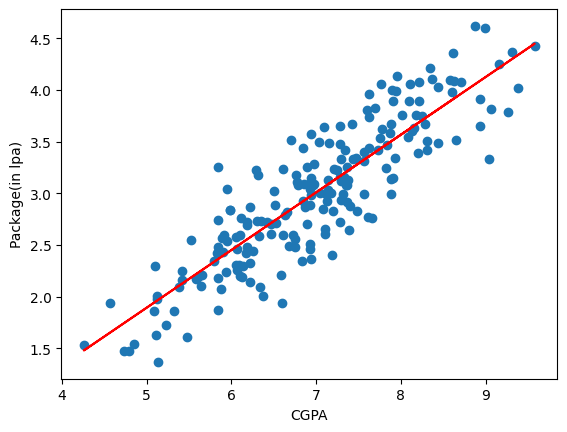

In [16]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_train,lr.predict(X_train),color='red')
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [71]:
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score, root_mean_squared_error

In [19]:
y_pred = lr.predict(X_test)

In [20]:
y_test.values

array([4.1 , 3.49, 2.08, 2.33, 1.94, 1.48, 1.86, 3.09, 4.21, 2.87, 3.65,
       4.  , 2.89, 2.6 , 2.99, 3.25, 1.86, 3.67, 2.37, 3.42, 2.48, 3.65,
       2.6 , 2.83, 4.08, 2.56, 3.58, 3.81, 4.09, 2.01, 3.63, 2.92, 3.51,
       1.94, 2.21, 3.34, 3.34, 3.23, 2.01, 2.61])

### MAE(mean absolute error)

In [23]:
print("MAE(in LPA)" , mean_absolute_error(y_test , y_pred))

MAE(in LPA) 0.2884710931878175


### MSE(mean squared error)

In [24]:
print("MSE (in LPA square) " , mean_squared_error(y_test , y_pred))

MSE (in LPA square)  0.12129235313495527


### RMSE(root MSE)

In [72]:
print("RMSE(in LPA)" , np.sqrt( mean_squared_error(y_test , y_pred)))
rmse_direct = root_mean_squared_error(y_test , y_pred)
rmse_direct

RMSE(in LPA) 0.30368977728886337


0.30368977728886337

### R2 Score

In [26]:
print("R2 Score" , r2_score(y_test , y_pred))

R2 Score 0.780730147510384


### Adjusted R2 Score

In [30]:
n= X_test.shape[0]
k = X_test.shape[1]

In [35]:
r2 = r2_score(y_test , y_pred)
R2_adj = 1-((1-r2)*(n-1))/(n-1-k)

In [36]:
R2_adj

0.7749598882343415

In [37]:
new_df1 = df.copy()
new_df1['random_feature'] = np.random.random(200)

new_df1 = new_df1[['cgpa','random_feature','package']]
new_df1.head()

,cgpa,random_feature,package
0,6.89,0.801239,3.26
1,5.12,0.641053,1.98
2,7.82,0.078271,3.25
3,7.42,0.017064,3.67
4,6.94,0.486576,3.57


In [38]:
new_df1.shape

(200, 3)

Text(0, 0.5, 'Package(in lpa)')

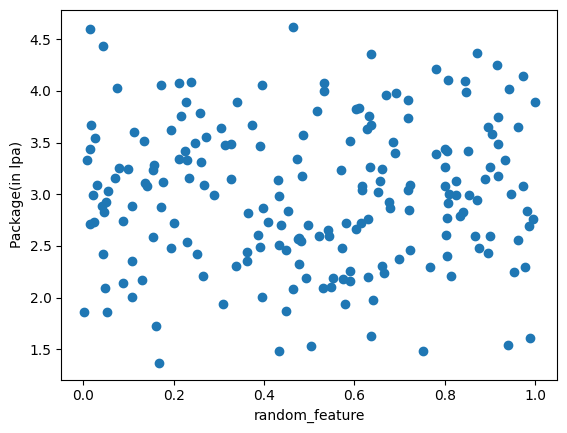

In [39]:
plt.scatter(new_df1['random_feature'],new_df1['package'])
plt.xlabel('random_feature')
plt.ylabel('Package(in lpa)')

In [40]:
X = new_df1.iloc[:,0:2]
y = new_df1.iloc[:,-1]


In [41]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)


In [42]:
lr = LinearRegression()

In [43]:
lr.fit(X_train , y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [44]:
y_pred = lr.predict(X_test)

In [45]:
print("R2 score",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2 score 0.7814184889130558


In [47]:
R2_adj = 1 - ((1-r2)*(40-1)/(40-1-2))
R2_adj

0.7696032720975452

In [61]:
new_df2 = df.copy()

new_df2['iq'] = new_df2['package'] + (np.random.randint(-12,12,200)/10)

new_df2 = new_df2[['cgpa','iq','package']]
new_df2.head()

,cgpa,iq,package
0,6.89,3.16,3.26
1,5.12,1.78,1.98
2,7.82,4.35,3.25
3,7.42,4.17,3.67
4,6.94,2.67,3.57


Text(0, 0.5, 'Package(in lpa)')

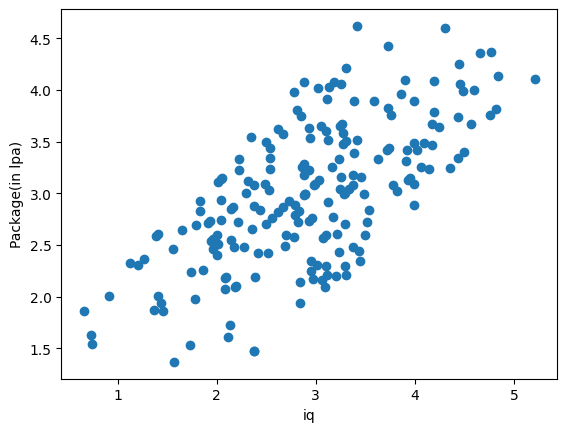

In [62]:
plt.scatter(new_df2['iq'],new_df2['package'])
plt.xlabel('iq')
plt.ylabel('Package(in lpa)')

In [63]:
X = new_df2.iloc[:,0:2]
y = new_df2.iloc[:,-1]

In [64]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)


In [65]:
lr = LinearRegression()

In [66]:
lr.fit(X_train , y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [67]:
y_pred = lr.predict(X_test)

In [68]:
print("R2 score",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)


R2 score 0.8332730333417676


In [69]:
R2_adj = 1 - ((1-r2)*(40-1)/(40-1-2))
R2_adj

0.824260764873755